# Feature Engineering

Calls `src/features.py` functions. No logic lives here.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import config
from src.features import compute_volatility_features

## Volatility Features

Five features per stock per week: RV at 5, 10, 21, 63 trading day lookbacks, plus RV(5d)/RV(63d) ratio.
1-step-ahead design: each value uses data through Friday of week T, predicting week T+1's RV.

In [2]:
# Load data produced by Phase 1
log_returns = pd.read_parquet(f"{config.DATA_RAW_DIR}/log_returns.parquet")
weekly_rv   = pd.read_parquet(f"{config.DATA_RAW_DIR}/weekly_rv.parquet")

vol_features = compute_volatility_features(log_returns, weekly_rv)
print("Shape:", vol_features.shape)
print("Feature names:", vol_features.columns.get_level_values(0).unique().tolist())

Shape: (573, 250)
Feature names: ['rv_5d', 'rv_10d', 'rv_21d', 'rv_63d', 'rv_ratio']


In [3]:
# Spot-check 1: RV values must be positive (ignoring NaN warm-up rows)
for feat in ["rv_5d", "rv_10d", "rv_21d", "rv_63d"]:
    vals = vol_features[feat].values
    non_nan = vals[~np.isnan(vals)]
    assert (non_nan >= 0).all(), f"{feat} contains negative values"
    print(f"{feat}: min={non_nan.min():.4f}  mean={non_nan.mean():.4f}  max={non_nan.max():.4f}")

ratio_vals = vol_features["rv_ratio"].values
ratio_non_nan = ratio_vals[~np.isnan(ratio_vals)]
print(f"rv_ratio: min={ratio_non_nan.min():.4f}  mean={ratio_non_nan.mean():.4f}  max={ratio_non_nan.max():.4f}")

rv_5d: min=0.0102  mean=0.2387  max=5.6861
rv_10d: min=0.0275  mean=0.2522  max=4.3792
rv_21d: min=0.0607  mean=0.2618  max=3.5477
rv_63d: min=0.0806  mean=0.2721  max=2.3355
rv_ratio: min=0.0512  mean=0.8919  max=3.5778


In [4]:
# Spot-check 2: RV_5d should be more variable than RV_63d (short-term vol is noisier)
std_5d  = vol_features["rv_5d"].stack().std()
std_63d = vol_features["rv_63d"].stack().std()
print(f"Cross-stock/time std — rv_5d: {std_5d:.4f}   rv_63d: {std_63d:.4f}")
assert std_5d > std_63d, "Expected rv_5d to be more variable than rv_63d"

# Spot-check 3: rv_ratio should spike during the March 2020 COVID week
# The week of 2020-03-16 should have an above-average ratio (short-term vol >> long-term baseline)
covid_week = pd.Timestamp("2020-03-16")
if covid_week in vol_features.index:
    median_ratio  = vol_features["rv_ratio"].median(axis=1)
    overall_median = median_ratio.median()
    covid_ratio    = median_ratio.loc[covid_week]
    print(f"Median rv_ratio — overall: {overall_median:.3f}   2020-03-16: {covid_ratio:.3f}")
    assert covid_ratio > overall_median * 2, (
        f"Expected COVID ratio >> overall median; got {covid_ratio:.3f} vs {overall_median:.3f}"
    )
else:
    print("2020-03-16 not in index (may be a holiday-shortened week that was dropped)")

Cross-stock/time std — rv_5d: 0.1848   rv_63d: 0.1359
Median rv_ratio — overall: 0.797   2020-03-16: 2.286


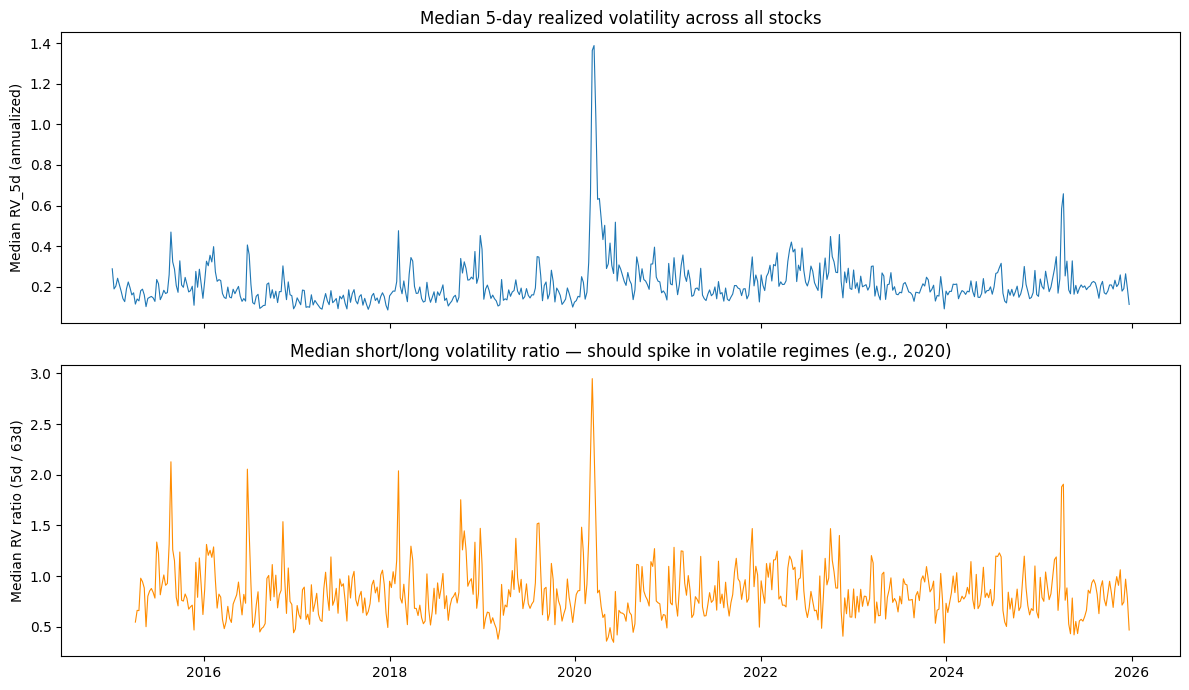

In [5]:
# Plot: median rv_5d and rv_ratio over time to visually confirm volatility clustering and COVID spike
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

median_rv5   = vol_features["rv_5d"].median(axis=1)
median_ratio = vol_features["rv_ratio"].median(axis=1)

axes[0].plot(median_rv5.index, median_rv5.values, linewidth=0.8)
axes[0].set_ylabel("Median RV_5d (annualized)")
axes[0].set_title("Median 5-day realized volatility across all stocks")

axes[1].plot(median_ratio.index, median_ratio.values, linewidth=0.8, color="darkorange")
axes[1].set_ylabel("Median RV ratio (5d / 63d)")
axes[1].set_title("Median short/long volatility ratio — should spike in volatile regimes (e.g., 2020)")

plt.tight_layout()
plt.show()

## Return and Volume Features

Five features: 5-day and 20-day cumulative log return (momentum), 5-day and 20-day mean volume, and the volume ratio.
All windows end at Friday of week T (1-step-ahead: predict week T+1 using data through end of week T).

In [6]:
from src.features import compute_return_volume_features

volume = pd.read_parquet(f"{config.DATA_RAW_DIR}/volume.parquet")
print("Volume shape:", volume.shape)

Volume shape: (2765, 50)


In [7]:
ret_vol_features = compute_return_volume_features(log_returns, volume, weekly_rv)
print("Shape:", ret_vol_features.shape)
print("Feature names:", ret_vol_features.columns.get_level_values(0).unique().tolist())

Shape: (573, 250)
Feature names: ['momentum_5d', 'momentum_20d', 'mean_vol_5d', 'mean_vol_20d', 'volume_ratio']


In [8]:
# Lagging verification: pick a specific week T and confirm momentum_5d equals
# the sum of log_returns over the 5 trading days OF week T (Monday through Friday).
# 1-step-ahead design: features at row T use data through Friday_T, predicting week T+1.
check_week   = weekly_rv.index[70]  # arbitrary week well past warm-up
check_ticker = weekly_rv.columns[0]

# 5 trading days of week T: on or after Monday_T, before Monday_{T+1}
week_days = log_returns.index[
    (log_returns.index >= check_week) &
    (log_returns.index < check_week + pd.Timedelta(days=7))
]
expected_momentum = log_returns.loc[week_days[:5], check_ticker].sum()
actual_momentum   = ret_vol_features.loc[check_week, ("momentum_5d", check_ticker)]

print(f"Check week  : {check_week.date()}")
print(f"5 days used : {week_days[0].date()} → {week_days[4].date()}")
print(f"Expected momentum_5d : {expected_momentum:.6f}")
print(f"Actual momentum_5d   : {actual_momentum:.6f}")
assert abs(expected_momentum - actual_momentum) < 1e-10, "Lagging alignment mismatch"
print("Lagging check passed.")

Check week  : 2016-05-09
5 days used : 2016-05-09 → 2016-05-13
Expected momentum_5d : 0.028318
Actual momentum_5d   : 0.028318
Lagging check passed.


In [9]:
# Spot-check volume features: mean volumes must be positive, ratio must be positive
for feat in ["mean_vol_5d", "mean_vol_20d", "volume_ratio"]:
    vals = ret_vol_features[feat].values
    non_nan = vals[~np.isnan(vals)]
    assert (non_nan > 0).all(), f"{feat} contains non-positive values"
    print(f"{feat}: min={non_nan.min():.0f}  median={np.median(non_nan):.0f}  max={non_nan.max():.0f}")

# Volume ratio should be centered near 1 (5d mean / 20d mean ≈ 1 in calm periods)
ratio_vals = ret_vol_features["volume_ratio"].stack().dropna()
print(f"\nvolume_ratio — mean: {ratio_vals.mean():.3f}  std: {ratio_vals.std():.3f}")
assert 0.5 < ratio_vals.mean() < 2.0, "Volume ratio mean far from 1 — check alignment"

mean_vol_5d: min=71740  median=2692560  max=400290400
mean_vol_20d: min=94165  median=2770332  max=310117960
volume_ratio: min=0  median=1  max=3

volume_ratio — mean: 1.003  std: 0.243


## Stacking, Winsorizing, and Normalizing

Build the full feature tensor: stack all 10 features, winsorize cross-sectionally at the 1st/99th percentile, then z-score cross-sectionally. Save to `data/features/features.parquet`.

In [10]:
from src.features import build_feature_tensor, save_features

features, feature_names = build_feature_tensor(weekly_rv, log_returns, volume)
print("Feature tensor shape:", features.shape)
print("Feature names:", feature_names)

Feature tensor shape: (573, 50, 10)
Feature names: ['rv_5d', 'rv_10d', 'rv_21d', 'rv_63d', 'rv_ratio', 'momentum_5d', 'momentum_20d', 'mean_vol_5d', 'mean_vol_20d', 'volume_ratio']


In [11]:
tickers = weekly_rv.columns.tolist()
weeks   = weekly_rv.index

save_features(features, feature_names, tickers, weeks)

Saved C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\features/features.parquet  shape=(28650, 12)


In [12]:
import json

with open(f"{config.DATA_FEATURES_DIR}/features_meta.json") as fh:
    meta = json.load(fh)
print("Saved shape:", meta["shape"])
print("Feature names:", meta["feature_names"])

# Normalization check: mean≈0, std≈1 at 10 random time steps after warm-up
rng = np.random.default_rng(config.RANDOM_SEED)
num_weeks, num_stocks, num_feats = features.shape
eligible = [i for i in range(63, num_weeks) if not np.isnan(features[i]).any()]
check_rows = rng.choice(eligible, size=min(10, len(eligible)), replace=False)

print(f"\nNormalization check at {len(check_rows)} random time steps:")
print(f"{'Feature':<16}  {'mean range':>22}  {'std range':>22}")
for f_idx, fname in enumerate(feature_names):
    means = [np.nanmean(features[t, :, f_idx]) for t in check_rows]
    stds  = [np.nanstd(features[t, :, f_idx])  for t in check_rows]
    print(f"  {fname:<14}  [{min(means):+.4f}, {max(means):+.4f}]  [{min(stds):.4f}, {max(stds):.4f}]")

Saved shape: [573, 50, 10]
Feature names: ['rv_5d', 'rv_10d', 'rv_21d', 'rv_63d', 'rv_ratio', 'momentum_5d', 'momentum_20d', 'mean_vol_5d', 'mean_vol_20d', 'volume_ratio']

Normalization check at 10 random time steps:
Feature                       mean range               std range
  rv_5d           [-0.0000, +0.0000]  [0.9899, 0.9899]
  rv_10d          [-0.0000, +0.0000]  [0.9899, 0.9899]
  rv_21d          [-0.0000, +0.0000]  [0.9899, 0.9899]
  rv_63d          [-0.0000, +0.0000]  [0.9899, 0.9899]
  rv_ratio        [-0.0000, +0.0000]  [0.9899, 0.9899]
  momentum_5d     [-0.0000, +0.0000]  [0.9899, 0.9899]
  momentum_20d    [-0.0000, +0.0000]  [0.9899, 0.9899]
  mean_vol_5d     [-0.0000, +0.0000]  [0.9899, 0.9899]
  mean_vol_20d    [-0.0000, +0.0000]  [0.9899, 0.9899]
  volume_ratio    [-0.0000, +0.0000]  [0.9899, 0.9899]


## Visualizations

### 1. Feature-feature correlation heatmap

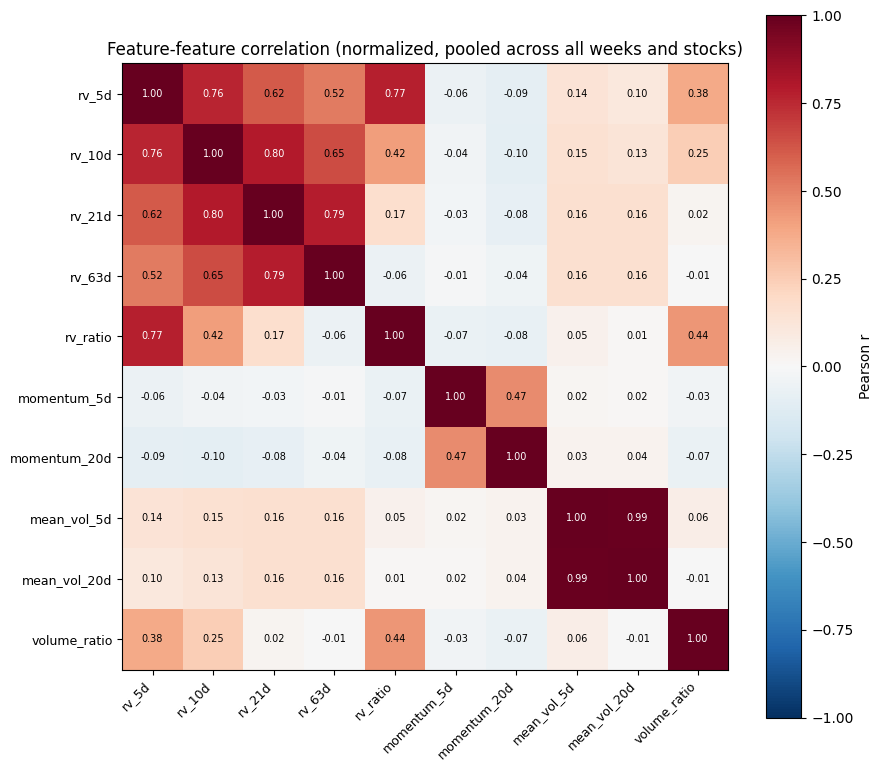

In [13]:
# Flatten across all weeks and stocks, compute feature-feature Pearson correlation
df_flat = pd.read_parquet(f"{config.DATA_FEATURES_DIR}/features.parquet")
feat_corr = df_flat[feature_names].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(feat_corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(feature_names, fontsize=9)
plt.colorbar(im, ax=ax, label="Pearson r")

# Annotate each cell with the correlation value
for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        ax.text(j, i, f"{feat_corr.values[i, j]:.2f}", ha="center", va="center",
                fontsize=7, color="black" if abs(feat_corr.values[i, j]) < 0.7 else "white")

ax.set_title("Feature-feature correlation (normalized, pooled across all weeks and stocks)")
plt.tight_layout()
plt.show()

### 2. Effect of winsorization and z-scoring on `rv_5d`

Raw values are right-skewed (fat tail). Winsorization clips the extremes. Z-scoring centers at 0 with unit variance.

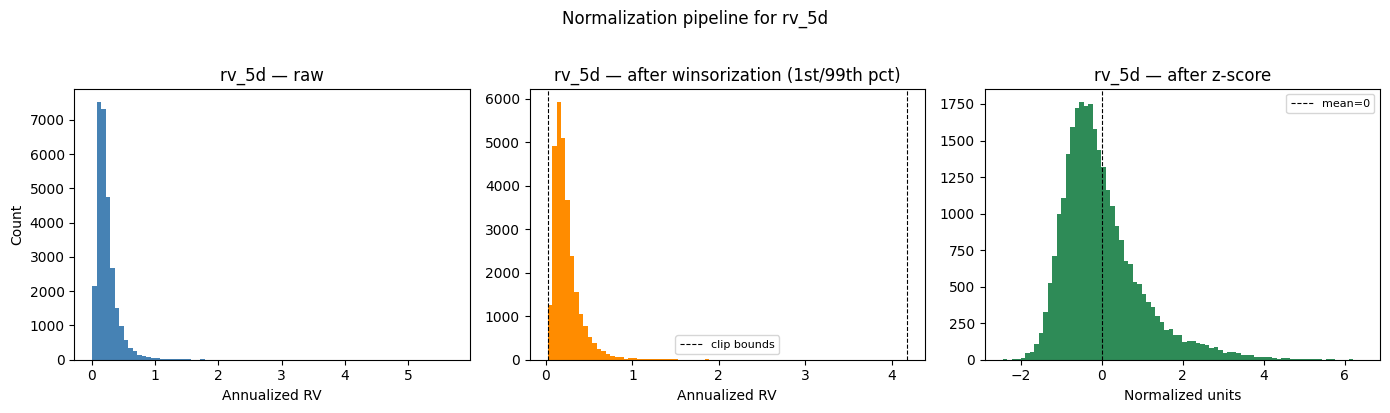

raw:  mean=0.239  std=0.185  max=5.686
wins: mean=0.237  std=0.175  max=4.175
norm: mean=0.000  std=0.990  max=6.433


In [14]:
from src.features import winsorize_cross_sectional, zscore_cross_sectional

rv5_raw_df   = vol_features["rv_5d"]
rv5_wins_df  = winsorize_cross_sectional(rv5_raw_df)
rv5_norm_idx = feature_names.index("rv_5d")
rv5_norm_arr = features[:, :, rv5_norm_idx].flatten()

rv5_raw  = rv5_raw_df.stack().dropna().values
rv5_wins = rv5_wins_df.stack().dropna().values
rv5_norm = rv5_norm_arr[~np.isnan(rv5_norm_arr)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(rv5_raw, bins=80, color="steelblue", edgecolor="none")
axes[0].set_title("rv_5d — raw")
axes[0].set_xlabel("Annualized RV")
axes[0].set_ylabel("Count")

axes[1].hist(rv5_wins, bins=80, color="darkorange", edgecolor="none")
axes[1].set_title("rv_5d — after winsorization (1st/99th pct)")
axes[1].set_xlabel("Annualized RV")
axes[1].axvline(rv5_wins.min(), color="k", linestyle="--", linewidth=0.8, label="clip bounds")
axes[1].axvline(rv5_wins.max(), color="k", linestyle="--", linewidth=0.8)
axes[1].legend(fontsize=8)

axes[2].hist(rv5_norm, bins=80, color="seagreen", edgecolor="none")
axes[2].set_title("rv_5d — after z-score")
axes[2].set_xlabel("Normalized units")
axes[2].axvline(0, color="k", linestyle="--", linewidth=0.8, label="mean=0")
axes[2].legend(fontsize=8)

plt.suptitle("Normalization pipeline for rv_5d", y=1.02)
plt.tight_layout()
plt.show()

print(f"raw:  mean={rv5_raw.mean():.3f}  std={rv5_raw.std():.3f}  max={rv5_raw.max():.3f}")
print(f"wins: mean={rv5_wins.mean():.3f}  std={rv5_wins.std():.3f}  max={rv5_wins.max():.3f}")
print(f"norm: mean={rv5_norm.mean():.3f}  std={rv5_norm.std():.3f}  max={np.abs(rv5_norm).max():.3f}")

### 3. Cross-sectional std over time

After normalization each feature should have cross-sectional std ≈ 1 at every time step. Deviations indicate weeks where the cross-section is unusually homogeneous (e.g., a market-wide shock collapses dispersion).

c:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\.venv\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


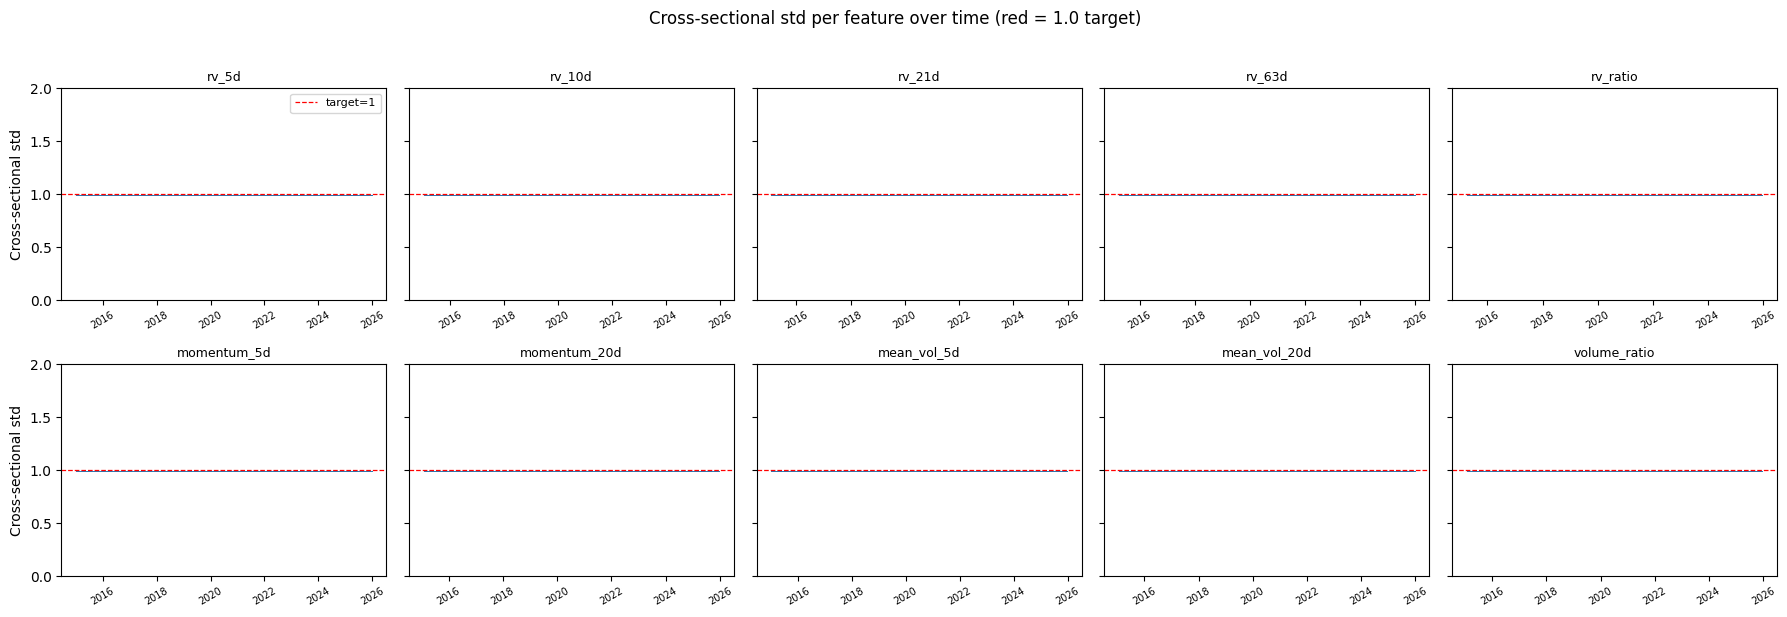

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=True)
axes_flat = axes.flatten()

for f_idx, fname in enumerate(feature_names):
    cs_std = pd.Series(
        [np.nanstd(features[t, :, f_idx]) for t in range(num_weeks)],
        index=weeks,
    )
    axes_flat[f_idx].plot(cs_std.index, cs_std.values, linewidth=0.7)
    axes_flat[f_idx].axhline(1.0, color="r", linestyle="--", linewidth=0.9, label="target=1")
    axes_flat[f_idx].set_title(fname, fontsize=9)
    axes_flat[f_idx].set_ylim(0, 2.0)
    axes_flat[f_idx].tick_params(axis="x", labelsize=7, rotation=30)

axes_flat[0].set_ylabel("Cross-sectional std")
axes_flat[5].set_ylabel("Cross-sectional std")
axes_flat[0].legend(fontsize=8)

plt.suptitle("Cross-sectional std per feature over time (red = 1.0 target)", y=1.02)
plt.tight_layout()
plt.show()

### 4. Normalized feature time series for a sample stock

Shows all 10 features for one stock over the full sample. Useful for checking that features move sensibly together (e.g., RV features spike together in 2020) and that no feature is flat or constant.

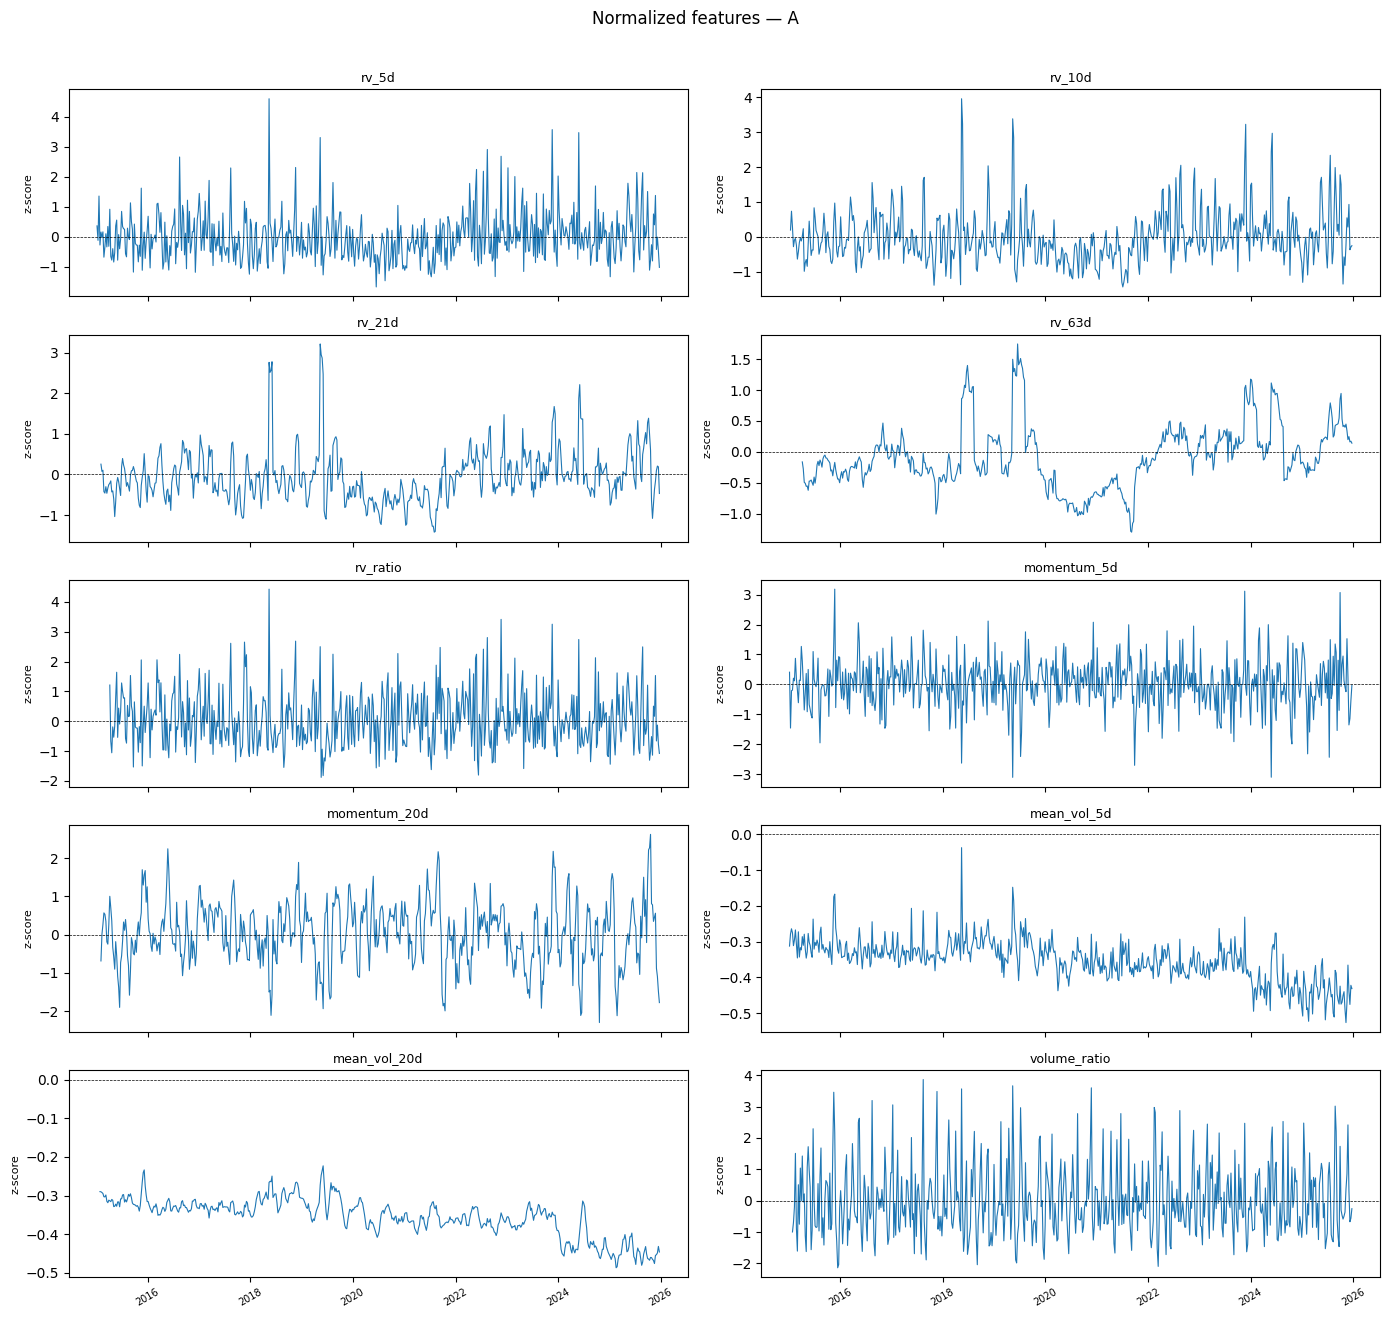

In [16]:
sample_ticker_idx = 0
sample_ticker     = tickers[sample_ticker_idx]

fig, axes = plt.subplots(5, 2, figsize=(14, 13), sharex=True)
axes_flat = axes.flatten()

for f_idx, fname in enumerate(feature_names):
    ts = features[:, sample_ticker_idx, f_idx]
    axes_flat[f_idx].plot(weeks, ts, linewidth=0.8)
    axes_flat[f_idx].axhline(0, color="k", linestyle="--", linewidth=0.5)
    axes_flat[f_idx].set_title(fname, fontsize=9)
    axes_flat[f_idx].set_ylabel("z-score", fontsize=8)
    axes_flat[f_idx].tick_params(axis="x", labelsize=7, rotation=30)

plt.suptitle(f"Normalized features — {sample_ticker}", y=1.01)
plt.tight_layout()
plt.show()

### 5. Cross-sectional dispersion over time (pre- vs post-normalization)

Compares the cross-sectional interquartile range of `rv_5d` before and after normalization. Pre-normalization, the IQR widens sharply during high-volatility regimes. Post-normalization it should be stable, confirming the z-scoring removes level effects.

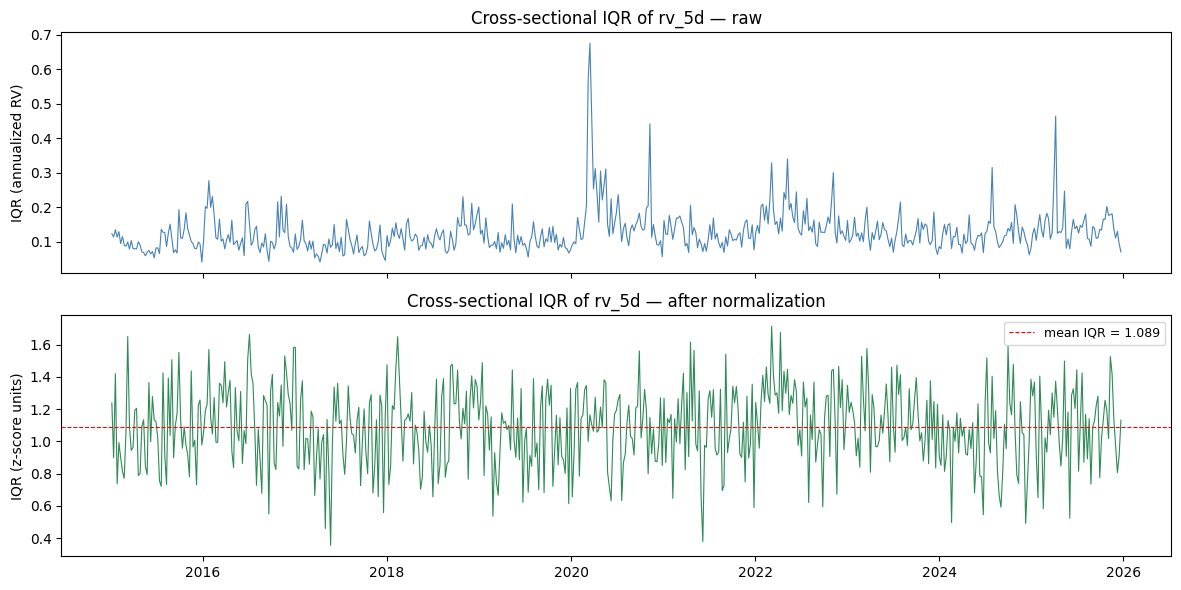

In [17]:
rv5_raw_df = vol_features["rv_5d"]   # (num_weeks, num_stocks), raw values

iqr_raw  = rv5_raw_df.quantile(0.75, axis=1) - rv5_raw_df.quantile(0.25, axis=1)

rv5_norm_idx  = feature_names.index("rv_5d")
rv5_norm_2d   = pd.DataFrame(features[:, :, rv5_norm_idx], index=weeks)
iqr_norm = rv5_norm_2d.quantile(0.75, axis=1) - rv5_norm_2d.quantile(0.25, axis=1)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(iqr_raw.index, iqr_raw.values, linewidth=0.8, color="steelblue")
axes[0].set_ylabel("IQR (annualized RV)")
axes[0].set_title("Cross-sectional IQR of rv_5d — raw")

axes[1].plot(iqr_norm.index, iqr_norm.values, linewidth=0.8, color="seagreen")
axes[1].axhline(iqr_norm.mean(), color="r", linestyle="--", linewidth=0.8, label=f"mean IQR = {iqr_norm.mean():.3f}")
axes[1].set_ylabel("IQR (z-score units)")
axes[1].set_title("Cross-sectional IQR of rv_5d — after normalization")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()